# Resume article tables

Training notebook for the resume dataset.
It builds article-aligned tables from direct model executions and keeps all outputs inside the notebook.


In [1]:
import os
from importlib.metadata import version, PackageNotFoundError

os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"
os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"

PACKAGES = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "matplotlib",
    "transformers",
    "accelerate",
    "tokenizers",
    "sentencepiece",
    "openpyxl",
    "torch",
]

def get_version(pkg_name):
    try:
        return version(pkg_name)
    except PackageNotFoundError:
        return "missing"
    except Exception:
        return "unknown"

env_table = {pkg: get_version(pkg) for pkg in PACKAGES}
env_table


{'numpy': '2.0.2',
 'pandas': '2.2.2',
 'scipy': '1.16.3',
 'scikit-learn': '1.6.1',
 'matplotlib': '3.10.0',
 'transformers': '5.0.0',
 'accelerate': '1.13.0',
 'tokenizers': '0.22.2',
 'sentencepiece': '0.2.1',
 'openpyxl': '3.1.5',
 'torch': '2.10.0+cu128'}

## Imports


In [2]:
import gc
import html
import math
import os
import random
import re
import time
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight

from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", message="Some weights of .* were not initialized")
warnings.filterwarnings("ignore", message=".*pooler.*")
warnings.filterwarnings("ignore", message=".*resume_download.*")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))


Torch: 2.10.0+cu128
CUDA available: True
Device: NVIDIA A100-SXM4-40GB


## Drive and paths


In [3]:
def find_file(candidates):
    for p in candidates:
        if p and Path(p).exists():
            return str(Path(p))
    raise FileNotFoundError(f"File not found. Tried: {candidates}")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
except Exception:
    pass

resume_path = find_file([
    "/content/drive/MyDrive/MLDL-NLP/DATASETS/CV/Resume.csv",
    "/content/drive/MyDrive/MLDL-NLP/DATASETS/CV/resume.csv",
    "/content/Resume.csv",
    "/content/resume.csv",
    "/mnt/data/Resume(4).csv",
    "/mnt/data/Resume(3).csv",
    "/mnt/data/resume.csv",
])

print("resume_path =", resume_path)


Mounted at /content/drive
resume_path = /content/drive/MyDrive/MLDL-NLP/DATASETS/CV/Resume.csv


## Configuration


In [4]:
CONFIG = {
    "seeds": [42, 43, 44],
    "max_length": 256,
    "epochs_transformer": 8,
    "epochs_lstm": 12,
    "batch_size_base": 8,
    "batch_size_large": 2,
    "grad_accum_base": 4,
    "grad_accum_large": 8,
    "learning_rate": 2.0e-5,
    "weight_decay": 1e-2,
    "warmup_ratio": 0.1,
    "dropout": 0.12,
    "cnn_filters": 256,
    "cnn_kernels_default": (2, 3, 4),
    "validation_size": 0.1,
    "num_workers": 2,
    "text_min_df": 2,
    "tfidf_max_features": 50000,
    "lstm_vocab_size": 50000,
    "lstm_embed_dim": 256,
    "lstm_hidden_dim": 256,
    "run_heavy_models": True,
    "early_stopping_patience": 4,
}

ARTICLE_LABEL_ORDER_25 = [
    "Advocate","Arts","Automation Testing","Blockchain","Business Analyst",
    "Civil Engineer","Data Base","Data Science","DevOps Engineer","DotNet Developer",
    "ETL Developer","Electrical Engineering","HR","Hadoop","Health and Fitness",
    "Java Developer","Mechanical Engineer","Network Security Engineer","Operations Manager",
    "PMO","Python Developer","SAP Developer","Sales","Testing","Web Designing",
]

LABEL_ALIASES = {
    "database": "Data Base",
    "data base": "Data Base",
    "data science": "Data Science",
    "health and fitness": "Health and Fitness",
    "health and fitness ": "Health and Fitness",
}


## Utilities


In [5]:

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def strip_html(raw_html: str) -> str:
    text = str(raw_html)
    text = re.sub(r"<[^>]+>", " ", text)
    text = html.unescape(text)
    return re.sub(r"\s+", " ", text).strip()

def normalize_text(text: str) -> str:
    text = str(text)
    text = html.unescape(text)
    text = re.sub(r"\s+", " ", text.replace("\x00", " ")).strip()
    return text

def canonicalize_label(label: str) -> str:
    raw = str(label).strip()
    key = re.sub(r"\s+", " ", raw).strip().lower()
    if key in LABEL_ALIASES:
        return LABEL_ALIASES[key]
    return re.sub(r"\s+", " ", raw).strip()

def infer_text_label_columns(df: pd.DataFrame):
    text_candidates = [c for c in df.columns if c.lower() in {"resume", "resume_str", "text", "cv", "content"}]
    label_candidates = [c for c in df.columns if c.lower() in {"category", "label", "class"}]
    text_col = text_candidates[0] if text_candidates else df.columns[0]
    label_col = label_candidates[0] if label_candidates else df.columns[-1]
    return text_col, label_col

def safe_hidden_size(model) -> int:
    cfg = model.config
    for attr in ["hidden_size", "dim", "d_model", "word_embed_proj_dim"]:
        if hasattr(cfg, attr):
            return int(getattr(cfg, attr))
    raise AttributeError("Could not infer hidden size from model config.")

def choose_label_order(labels):
    labels = list(labels)
    if set(labels) == set(ARTICLE_LABEL_ORDER_25):
        return ARTICLE_LABEL_ORDER_25
    return sorted(labels)

def format_pct(x):
    if pd.isna(x):
        return np.nan
    return round(float(x) * 100.0, 2)

def memory_gb():
    if not torch.cuda.is_available():
        return np.nan
    return torch.cuda.max_memory_allocated() / (1024 ** 3)

def cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def multiclass_auc(y_true, probas, classes):
    try:
        y_true_bin = label_binarize(y_true, classes=classes)
        return roc_auc_score(y_true_bin, probas, multi_class="ovr", average="macro")
    except Exception:
        return np.nan


def count_parameters(model: nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))



def plot_history(history, title):
    if history is None:
        return
    if isinstance(history, dict):
        history = [history]
    if not history:
        return
    hist_df = pd.DataFrame(history)
    if hist_df.empty or "epoch" not in hist_df.columns:
        return

    plt.figure(figsize=(8, 4))
    has_any = False
    for col in ["train_loss", "val_loss", "train_acc", "val_acc", "val_macro_f1"]:
        if col in hist_df.columns and hist_df[col].notna().any():
            plt.plot(hist_df["epoch"], hist_df[col], marker="o", label=col.replace("_", " ").title())
            has_any = True
    if not has_any:
        plt.close()
        return
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [6]:

def idf_tokenize(text: str):
    text = normalize_text(text).lower()
    tokens = re.findall(r"[a-z0-9][a-z0-9\+\#\.-]*", text)
    return tokens

def build_idf_dictionary(texts):
    doc_freq = Counter()
    n_docs = 0
    for text in texts:
        toks = set(idf_tokenize(text))
        if not toks:
            continue
        doc_freq.update(toks)
        n_docs += 1
    if n_docs == 0:
        return {}, 1.0
    idf = {
        tok: float(math.log((1.0 + n_docs) / (1.0 + df)) + 1.0)
        for tok, df in doc_freq.items()
    }
    default_idf = float(math.log((1.0 + n_docs) / 1.0) + 1.0)
    return idf, default_idf


## Data loading


In [7]:
raw_df = pd.read_csv(resume_path)

if {"Resume_str", "Resume_html", "Category"}.issubset(raw_df.columns):
    text_primary = raw_df["Resume_str"].fillna("").astype(str).map(normalize_text)
    text_html = raw_df["Resume_html"].fillna("").astype(str).map(strip_html)
    merged_text = []
    for a, b in zip(text_primary, text_html):
        parts = [p for p in [a, b] if p]
        merged_text.append(" ".join(parts).strip())
    df = pd.DataFrame({"text": merged_text, "label": raw_df["Category"].astype(str)})
else:
    text_col, label_col = infer_text_label_columns(raw_df)
    df = raw_df[[text_col, label_col]].copy()
    df.columns = ["text", "label"]
    df["text"] = df["text"].astype(str).map(normalize_text)

df["label"] = df["label"].astype(str).map(canonicalize_label)
df["text"] = df["text"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df = df[df["text"].str.len() > 0].dropna().reset_index(drop=True)

label_order = choose_label_order(df["label"].unique())
label_encoder = LabelEncoder()
label_encoder.fit(label_order)
df["label_id"] = label_encoder.transform(df["label"])

full_counts = df["label"].value_counts().reindex(label_order, fill_value=0)
display(full_counts.to_frame("count"))

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_core_df, valid_df = train_test_split(
    train_df,
    test_size=CONFIG["validation_size"],
    random_state=42,
    stratify=train_df["label_id"],
)
train_core_df = train_core_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

idf_dict, default_idf = build_idf_dictionary(train_df["text"].tolist())
idf_values = np.array(list(idf_dict.values()), dtype=np.float32)
idf_min = float(idf_values.min()) if len(idf_values) else 1.0
idf_max = float(idf_values.max()) if len(idf_values) else 1.0
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(label_order)),
    y=train_core_df["label_id"].to_numpy(),
).astype(np.float32)
class_weights_tensor = torch.tensor(class_weight_values, dtype=torch.float32, device=device)

print("Dataset size:", len(df))
print("Train / Valid / Test:", len(train_core_df), len(valid_df), len(test_df))
print("Classes:", len(label_order))

,count
label,
ACCOUNTANT,118
ADVOCATE,118
AGRICULTURE,63
APPAREL,97
ARTS,103
AUTOMOBILE,36
AVIATION,117
BANKING,115
BPO,22


Dataset size: 2483
Train / Valid / Test: 1787 199 497
Classes: 24


## Classical baselines


In [8]:
def run_classical_models(train_df, test_df):
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=CONFIG["text_min_df"],
        max_features=CONFIG["tfidf_max_features"],
        sublinear_tf=True,
    )
    X_train = vectorizer.fit_transform(train_df["text"])
    X_test = vectorizer.transform(test_df["text"])
    y_train = train_df["label_id"].to_numpy()
    y_test = test_df["label_id"].to_numpy()

    models = {
        "SVM (TF-IDF)": LinearSVC(),
        "LogReg (TF-IDF)": LogisticRegression(max_iter=2000, n_jobs=None),
        "MultinomialNB": MultinomialNB(),
        "Random Forest": RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    }

    outputs = {}
    for name, model in models.items():
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        train_seconds = time.perf_counter() - t0

        t1 = time.perf_counter()
        preds = model.predict(X_test)
        infer_seconds = time.perf_counter() - t1

        if hasattr(model, "predict_proba"):
            probas = model.predict_proba(X_test)
        else:
            scores = model.decision_function(X_test)
            if scores.ndim == 1:
                scores = np.vstack([-scores, scores]).T
            exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True))
            probas = exp_scores / exp_scores.sum(axis=1, keepdims=True)

        report = classification_report(
            y_test,
            preds,
            labels=np.arange(len(label_order)),
            target_names=label_order,
            zero_division=0,
            output_dict=True,
        )
        outputs[name] = {
            "y_true": y_test,
            "y_pred": preds,
            "probas": probas,
            "accuracy": accuracy_score(y_test, preds),
            "macro_f1": f1_score(y_test, preds, average="macro"),
            "macro_precision": precision_recall_fscore_support(y_test, preds, average="macro", zero_division=0)[0],
            "macro_recall": precision_recall_fscore_support(y_test, preds, average="macro", zero_division=0)[1],
            "report": report,
            "train_time_epoch_s": train_seconds,
            "inference_total_s": infer_seconds,
            "params": np.nan,
            "gpu_memory_gb": np.nan,
            "history": [],
        }
    return outputs

classical_outputs = run_classical_models(train_df, test_df)
pd.DataFrame(
    [
        {"Model": name, "Accuracy": round(v["accuracy"], 4), "Macro F1": round(v["macro_f1"], 4)}
        for name, v in classical_outputs.items()
    ]
).sort_values(["Accuracy", "Macro F1"], ascending=False)


,Model,Accuracy,Macro F1
3,Random Forest,0.7082,0.6339
0,SVM (TF-IDF),0.6841,0.6355
1,LogReg (TF-IDF),0.6117,0.5314
2,MultinomialNB,0.5151,0.4182


## Word-level BiLSTM baseline


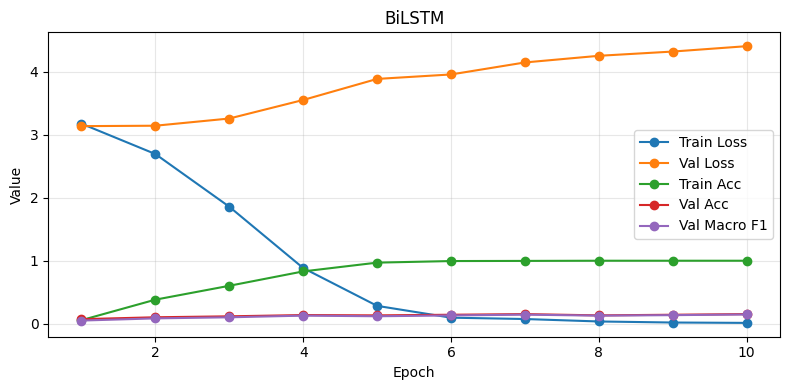

{'accuracy': 0.1429, 'macro_f1': 0.1275}


In [9]:
class WordVocab:
    def __init__(self, texts, max_size=30000):
        counter = Counter()
        for text in texts:
            counter.update(re.findall(r"[A-Za-z][A-Za-z\+\#\.-]+", text.lower()))
        vocab = ["[PAD]", "[UNK]"] + [w for w, _ in counter.most_common(max_size - 2)]
        self.stoi = {w: i for i, w in enumerate(vocab)}
        self.itos = vocab

    def encode(self, text, max_length=256):
        ids = [self.stoi.get(tok, 1) for tok in re.findall(r"[A-Za-z][A-Za-z\+\#\.-]+", text.lower())[:max_length]]
        if len(ids) < max_length:
            ids += [0] * (max_length - len(ids))
        return ids

class WordDataset(Dataset):
    def __init__(self, frame, vocab, max_length=256):
        self.texts = frame["text"].tolist()
        self.labels = frame["label_id"].tolist()
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.vocab.encode(self.texts[idx], self.max_length), dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, embed_dim=200, hidden_dim=192, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, labels=None):
        x = self.embedding(input_ids)
        out, _ = self.lstm(x)
        feat = out[:, -1, :]
        logits = self.fc(self.dropout(feat))
        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits.float(), labels)
        return {"loss": loss, "logits": logits}

def collate_word(batch):
    return {
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "labels": torch.stack([b["labels"] for b in batch]),
    }

def run_lstm_baseline(train_core_df, valid_df, test_df):
    seed_everything(42)
    vocab = WordVocab(train_core_df["text"].tolist(), max_size=CONFIG["lstm_vocab_size"])
    train_ds = WordDataset(train_core_df, vocab)
    valid_ds = WordDataset(valid_df, vocab)
    test_ds = WordDataset(test_df, vocab)

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_word)
    valid_loader = DataLoader(valid_ds, batch_size=128, shuffle=False, collate_fn=collate_word)
    test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, collate_fn=collate_word)

    model = BiLSTMClassifier(
        vocab_size=len(vocab.itos),
        num_classes=len(label_order),
        embed_dim=CONFIG["lstm_embed_dim"],
        hidden_dim=CONFIG["lstm_hidden_dim"],
        dropout=CONFIG["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)
    best_state, best_f1 = None, -1.0
    history = []

    for epoch in range(1, CONFIG["epochs_lstm"] + 1):
        model.train()
        train_losses = []
        train_preds, train_labels = [], []
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            out["loss"].backward()
            optimizer.step()
            train_losses.append(out["loss"].item())
            train_preds.extend(out["logits"].argmax(dim=1).detach().cpu().numpy().tolist())
            train_labels.extend(batch["labels"].detach().cpu().numpy().tolist())

        model.eval()
        preds, labels = [], []
        valid_losses = []
        with torch.no_grad():
            for batch in valid_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                out = model(**batch)
                valid_losses.append(out["loss"].item())
                preds.extend(out["logits"].argmax(dim=1).cpu().numpy().tolist())
                labels.extend(batch["labels"].cpu().numpy().tolist())

        val_f1 = f1_score(labels, preds, average="macro")
        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(train_losses)),
                "val_loss": float(np.mean(valid_losses)),
                "train_acc": accuracy_score(train_labels, train_preds),
                "val_acc": accuracy_score(labels, preds),
                "val_macro_f1": val_f1,
            }
        )
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    preds, labels, probas = [], [], []
    t0 = time.perf_counter()
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            p = torch.softmax(out["logits"], dim=1).cpu().numpy()
            probas.append(p)
            preds.extend(p.argmax(axis=1).tolist())
            labels.extend(batch["labels"].cpu().numpy().tolist())
    infer_seconds = time.perf_counter() - t0
    probas = np.concatenate(probas, axis=0)
    report = classification_report(labels, preds, labels=np.arange(len(label_order)), target_names=label_order, zero_division=0, output_dict=True)

    return {
        "y_true": np.array(labels),
        "y_pred": np.array(preds),
        "probas": probas,
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "macro_precision": precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)[0],
        "macro_recall": precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)[1],
        "report": report,
        "train_time_epoch_s": np.nan,
        "inference_total_s": infer_seconds,
        "params": count_parameters(model),
        "gpu_memory_gb": np.nan,
        "history": history,
    }

lstm_output = run_lstm_baseline(train_core_df, valid_df, test_df)
plot_history(lstm_output["history"], "BiLSTM")
print({"accuracy": round(lstm_output["accuracy"], 4), "macro_f1": round(lstm_output["macro_f1"], 4)})


## Transformer datasets and models


In [10]:

class TransformerDataset(Dataset):
    def __init__(self, frame, tokenizer, max_length, use_idf=False, idf_dict=None, default_idf=1.0, idf_alpha=1.0):
        self.frame = frame.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.use_idf = use_idf
        self.idf_dict = idf_dict or {}
        self.default_idf = default_idf
        self.idf_alpha = idf_alpha
        self.has_token_type_ids = "token_type_ids" in tokenizer.model_input_names

    def __len__(self):
        return len(self.frame)

    def _normalize_idf(self, value: float) -> float:
        denom = max(idf_max - idf_min, 1e-6)
        scaled = 1.0 + self.idf_alpha * ((float(value) - idf_min) / denom)
        return float(np.clip(scaled, 1.0, 2.0))

    def _idf_weights(self, text, encoding):
        offsets = encoding["offset_mapping"]
        weights = []
        clean_text = text.lower()
        for start, end in offsets:
            if end <= start:
                weights.append(0.0)
                continue
            token_text = clean_text[start:end].strip().lower()
            token_text = re.sub(r"[^a-z0-9\+\#\.-]+", "", token_text)
            if not token_text:
                weights.append(0.0)
            else:
                raw_idf = float(self.idf_dict.get(token_text, self.default_idf))
                weights.append(self._normalize_idf(raw_idf))
        if len(weights) < self.max_length:
            weights += [0.0] * (self.max_length - len(weights))
        return weights[:self.max_length]

    def __getitem__(self, idx):
        text = self.frame.loc[idx, "text"]
        label = int(self.frame.loc[idx, "label_id"])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors=None,
            return_offsets_mapping=True,
        )
        item = {
            "input_ids": torch.tensor(encoding["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(encoding["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(label, dtype=torch.long),
        }
        if self.has_token_type_ids and "token_type_ids" in encoding:
            item["token_type_ids"] = torch.tensor(encoding["token_type_ids"], dtype=torch.long)
        if self.use_idf:
            item["idf_weights"] = torch.tensor(self._idf_weights(text, encoding), dtype=torch.float32)
        return item

def collate_transformer(batch):
    keys = batch[0].keys()
    return {k: torch.stack([item[k] for item in batch]) for k in keys}

class TransformerClassifier(nn.Module):
    def __init__(
        self,
        backbone,
        num_classes,
        dropout=0.2,
        use_cnn=False,
        use_idf=False,
        kernels=(2, 3, 4),
        filters=128,
        attention_variant="cls",
        cls_fusion=True,
        avg_fusion=False,
        gradient_checkpointing=False,
        class_weights=None,
        label_smoothing=0.0,
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(backbone)
        if gradient_checkpointing and hasattr(self.encoder, "gradient_checkpointing_enable"):
            self.encoder.gradient_checkpointing_enable()
        self.hidden_size = safe_hidden_size(self.encoder)
        self.use_cnn = use_cnn
        self.use_idf = use_idf
        self.attention_variant = attention_variant
        self.cls_fusion = cls_fusion and use_cnn
        self.avg_fusion = avg_fusion and use_cnn
        self.label_smoothing = float(label_smoothing)

        if class_weights is not None:
            self.register_buffer("class_weights", class_weights.clone().detach().float())
        else:
            self.class_weights = None

        if use_cnn:
            self.convs = nn.ModuleList(
                [nn.Conv1d(self.hidden_size, filters, kernel_size=k, padding=0) for k in kernels]
            )
            extra = 0
            if self.cls_fusion:
                extra += self.hidden_size
            if self.avg_fusion:
                extra += self.hidden_size
            out_dim = filters * len(kernels) + extra
        elif attention_variant == "softmax_token":
            self.attn_proj = nn.Linear(self.hidden_size, self.hidden_size)
            self.attn_score = nn.Linear(self.hidden_size, 1)
            out_dim = self.hidden_size
        elif attention_variant == "gate":
            self.gate = nn.Linear(self.hidden_size, 1)
            out_dim = self.hidden_size
        elif attention_variant == "layer_scale":
            self.scale = nn.Parameter(torch.ones(self.hidden_size))
            out_dim = self.hidden_size
        else:
            out_dim = self.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(out_dim, num_classes)

    def _pool_tokens(self, token_embeddings, attention_mask):
        if self.attention_variant == "cls":
            return token_embeddings[:, 0, :]
        mask = attention_mask.unsqueeze(-1).float()
        if self.attention_variant == "mean":
            summed = (token_embeddings * mask).sum(dim=1)
            denom = mask.sum(dim=1).clamp(min=1.0)
            return summed / denom
        if self.attention_variant == "softmax_token":
            scores = self.attn_score(torch.tanh(self.attn_proj(token_embeddings))).squeeze(-1)
            scores = scores.masked_fill(attention_mask == 0, -1e9)
            weights = torch.softmax(scores, dim=1).unsqueeze(-1)
            return (token_embeddings * weights).sum(dim=1)
        if self.attention_variant == "gate":
            gate = torch.sigmoid(self.gate(token_embeddings))
            weighted = token_embeddings * gate * mask
            denom = mask.sum(dim=1).clamp(min=1.0)
            return weighted.sum(dim=1) / denom
        if self.attention_variant == "layer_scale":
            scaled = token_embeddings * self.scale
            return scaled[:, 0, :]
        return token_embeddings[:, 0, :]

    def forward(self, input_ids, attention_mask, labels=None, token_type_ids=None, idf_weights=None):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids
        outputs = self.encoder(**kwargs)
        x = outputs.last_hidden_state

        if self.use_idf and idf_weights is not None:
            x = x * idf_weights.unsqueeze(-1).to(x.dtype)

        if self.use_cnn:
            conv_in = x.transpose(1, 2)
            pooled = []
            for conv in self.convs:
                conv_input = conv_in.to(conv.weight.dtype)
                h = F.gelu(conv(conv_input))
                pooled.append(F.max_pool1d(h, kernel_size=h.shape[-1]).squeeze(-1))
            feat = torch.cat(pooled, dim=1)
            if self.cls_fusion:
                cls_feat = x[:, 0, :].to(feat.dtype)
                feat = torch.cat([feat, cls_feat], dim=1)
            if self.avg_fusion:
                mask = attention_mask.unsqueeze(-1).to(x.dtype)
                avg_feat = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
                feat = torch.cat([feat, avg_feat.to(feat.dtype)], dim=1)
        else:
            feat = self._pool_tokens(x, attention_mask)

        feat = feat.to(self.classifier.weight.dtype)
        logits = self.classifier(self.dropout(feat))
        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits.float(),
                labels,
                weight=(self.class_weights.float() if self.class_weights is not None else None),
                label_smoothing=self.label_smoothing,
            )
        return {"loss": loss, "logits": logits, "features": feat}


## Training engine


In [11]:

def make_loader(frame, tokenizer, max_length, batch_size, shuffle, use_idf=False, idf_alpha=1.0):
    ds = TransformerDataset(
        frame=frame,
        tokenizer=tokenizer,
        max_length=max_length,
        use_idf=use_idf,
        idf_dict=idf_dict,
        default_idf=default_idf,
        idf_alpha=idf_alpha,
    )
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=CONFIG["num_workers"],
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_transformer,
    )

def evaluate_transformer(model, loader):
    model.eval()
    preds, labels, probas = [], [], []
    losses = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            loss = out["loss"]
            if loss is not None:
                losses.append(loss.item())
            p = torch.softmax(out["logits"].float(), dim=1).detach().cpu().numpy()
            probas.append(p)
            preds.extend(p.argmax(axis=1).tolist())
            labels.extend(batch["labels"].detach().cpu().numpy().tolist())
    probas = np.concatenate(probas, axis=0)
    metrics = {
        "loss": float(np.mean(losses)) if losses else np.nan,
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "macro_precision": precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)[0],
        "macro_recall": precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)[1],
        "auc_macro": multiclass_auc(labels, probas, classes=np.arange(len(label_order))),
        "y_true": np.array(labels),
        "y_pred": np.array(preds),
        "probas": probas,
        "report": classification_report(
            labels,
            preds,
            labels=np.arange(len(label_order)),
            target_names=label_order,
            zero_division=0,
            output_dict=True,
        ),
    }
    return metrics

def train_transformer_spec(spec, seed):
    seed_everything(seed)
    cleanup()

    tokenizer = AutoTokenizer.from_pretrained(spec["backbone"], use_fast=True)
    batch_size = spec.get("batch_size", CONFIG["batch_size_base"])
    grad_accum = spec.get("grad_accum", CONFIG["grad_accum_base"])

    train_loader = make_loader(
        train_core_df,
        tokenizer,
        spec["max_length"],
        batch_size,
        True,
        use_idf=spec["use_idf"],
        idf_alpha=spec.get("idf_alpha", 1.0),
    )
    valid_loader = make_loader(
        valid_df,
        tokenizer,
        spec["max_length"],
        batch_size * 2,
        False,
        use_idf=spec["use_idf"],
        idf_alpha=spec.get("idf_alpha", 1.0),
    )
    test_loader = make_loader(
        test_df,
        tokenizer,
        spec["max_length"],
        batch_size * 2,
        False,
        use_idf=spec["use_idf"],
        idf_alpha=spec.get("idf_alpha", 1.0),
    )

    model = TransformerClassifier(
        backbone=spec["backbone"],
        num_classes=len(label_order),
        dropout=spec.get("dropout", CONFIG["dropout"]),
        use_cnn=spec.get("use_cnn", False),
        use_idf=spec.get("use_idf", False),
        kernels=spec.get("kernels", CONFIG["cnn_kernels_default"]),
        filters=spec.get("filters", CONFIG["cnn_filters"]),
        attention_variant=spec.get("attention_variant", "cls"),
        cls_fusion=spec.get("cls_fusion", True),
        avg_fusion=spec.get("avg_fusion", False),
        gradient_checkpointing=spec.get("gradient_checkpointing", False),
        class_weights=(class_weights_tensor if spec.get("use_class_weights", False) else None),
        label_smoothing=spec.get("label_smoothing", 0.0),
    ).to(device).float()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=spec.get("lr", CONFIG["learning_rate"]),
        weight_decay=spec.get("weight_decay", CONFIG["weight_decay"]),
    )
    total_steps = max(int(np.ceil(len(train_loader) / grad_accum)), 1) * spec["epochs"]
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(int(total_steps * spec.get("warmup_ratio", CONFIG["warmup_ratio"])), 1),
        num_training_steps=total_steps,
    )

    best_state = None
    best_valid = -1.0
    best_epoch = 0
    epochs_without_improve = 0
    history = []
    epoch_train_times = []

    for epoch in range(1, spec["epochs"] + 1):
        model.train()
        start_epoch = time.perf_counter()
        optimizer.zero_grad(set_to_none=True)
        running_loss = []
        train_preds, train_labels = [], []

        for step, batch in enumerate(train_loader, start=1):
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            loss = out["loss"] / grad_accum
            loss.backward()

            logits_now = out["logits"].detach()
            train_preds.extend(logits_now.argmax(dim=1).cpu().numpy().tolist())
            train_labels.extend(batch["labels"].detach().cpu().numpy().tolist())

            if step % grad_accum == 0 or step == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

            running_loss.append(loss.item() * grad_accum)

        epoch_train_times.append(time.perf_counter() - start_epoch)
        valid_metrics = evaluate_transformer(model, valid_loader)
        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(running_loss)),
                "val_loss": valid_metrics["loss"],
                "train_acc": accuracy_score(train_labels, train_preds),
                "val_acc": valid_metrics["accuracy"],
                "val_macro_f1": valid_metrics["macro_f1"],
            }
        )

        if valid_metrics["macro_f1"] > best_valid:
            best_valid = valid_metrics["macro_f1"]
            best_epoch = epoch
            epochs_without_improve = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improve += 1
            if epochs_without_improve >= spec.get("patience", CONFIG["early_stopping_patience"]):
                break

    model.load_state_dict(best_state)

    if spec.get("refit_on_full_train", False):
        cleanup()
        full_train_df = pd.concat([train_core_df, valid_df], axis=0).reset_index(drop=True)
        full_train_loader = make_loader(
            full_train_df,
            tokenizer,
            spec["max_length"],
            batch_size,
            True,
            use_idf=spec["use_idf"],
            idf_alpha=spec.get("idf_alpha", 1.0),
        )
        model = TransformerClassifier(
            backbone=spec["backbone"],
            num_classes=len(label_order),
            dropout=spec.get("dropout", CONFIG["dropout"]),
            use_cnn=spec.get("use_cnn", False),
            use_idf=spec.get("use_idf", False),
            kernels=spec.get("kernels", CONFIG["cnn_kernels_default"]),
            filters=spec.get("filters", CONFIG["cnn_filters"]),
            attention_variant=spec.get("attention_variant", "cls"),
            cls_fusion=spec.get("cls_fusion", True),
            avg_fusion=spec.get("avg_fusion", False),
            gradient_checkpointing=spec.get("gradient_checkpointing", False),
            class_weights=(class_weights_tensor if spec.get("use_class_weights", False) else None),
            label_smoothing=spec.get("label_smoothing", 0.0),
        ).to(device).float()
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=spec.get("lr", CONFIG["learning_rate"]),
            weight_decay=spec.get("weight_decay", CONFIG["weight_decay"]),
        )
        total_steps_refit = max(int(np.ceil(len(full_train_loader) / grad_accum)), 1) * max(best_epoch, 1)
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=max(int(total_steps_refit * spec.get("warmup_ratio", CONFIG["warmup_ratio"])), 1),
            num_training_steps=total_steps_refit,
        )
        optimizer.zero_grad(set_to_none=True)
        for epoch in range(max(best_epoch, 1)):
            model.train()
            for step, batch in enumerate(full_train_loader, start=1):
                batch = {k: v.to(device) for k, v in batch.items()}
                out = model(**batch)
                loss = out["loss"] / grad_accum
                loss.backward()
                if step % grad_accum == 0 or step == len(full_train_loader):
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad(set_to_none=True)

    cleanup()
    infer_t0 = time.perf_counter()
    test_metrics = evaluate_transformer(model, test_loader)
    infer_seconds = time.perf_counter() - infer_t0
    gpu_mem = memory_gb()
    params = count_parameters(model)

    return {
        **test_metrics,
        "train_time_epoch_s": float(np.mean(epoch_train_times)) if epoch_train_times else np.nan,
        "inference_total_s": infer_seconds,
        "params": params,
        "gpu_memory_gb": gpu_mem,
        "history": history,
        "spec": spec,
        "seed": seed,
        "model_state": ({k: v.detach().cpu().clone() for k, v in model.state_dict().items()} if spec.get("keep_state", False) else None),
        "tokenizer_name": spec["backbone"],
    }

def expand_search_space(spec):
    search_space = spec.get("search_space")
    if not search_space:
        return [spec]
    variants = []
    for variant in search_space:
        merged = dict(spec)
        merged.update(variant)
        merged.pop("search_space", None)
        merged["name"] = spec["name"]
        variants.append(merged)
    return variants

def run_transformer_suite(specs):
    outputs = {}
    for spec in specs:
        variants = expand_search_space(spec)
        best_run = None
        best_history = None
        for variant_idx, variant in enumerate(variants, start=1):
            all_runs = []
            for seed in CONFIG["seeds"]:
                print(f'{spec["name"]} | variant {variant_idx}/{len(variants)} | seed {seed}')
                run = train_transformer_spec(variant, seed)
                all_runs.append(run)
                cleanup()
            candidate = max(all_runs, key=lambda x: (x["macro_f1"], x["accuracy"]))
            if best_run is None or (candidate["macro_f1"], candidate["accuracy"]) > (best_run["macro_f1"], best_run["accuracy"]):
                best_run = candidate
        outputs[spec["name"]] = best_run
        plot_history(best_run["history"], spec["name"])
    return outputs


## Model suites


In [12]:
core_specs = [
    {
        "name": "BERTBASE",
        "backbone": "bert-base-uncased",
        "use_cnn": False,
        "use_idf": False,
        "attention_variant": "mean",
        "epochs": 6,
        "max_length": 256,
        "dropout": 0.12,
        "lr": 2.0e-5,
        "warmup_ratio": 0.1,
        "keep_state": True,
        "use_class_weights": True,
        "label_smoothing": 0.01,
    },
    {
        "name": "BERTBASE+CNN",
        "backbone": "bert-base-uncased",
        "use_cnn": True,
        "use_idf": False,
        "kernels": (2, 3, 4, 5),
        "filters": 224,
        "epochs": 7,
        "max_length": 256,
        "dropout": 0.10,
        "lr": 1.8e-5,
        "warmup_ratio": 0.1,
        "avg_fusion": True,
        "cls_fusion": True,
        "use_class_weights": True,
        "label_smoothing": 0.02,
    },
    {
        "name": "BERTIDF-CNN (Ours)",
        "backbone": "bert-base-uncased",
        "use_cnn": True,
        "use_idf": True,
        "kernels": (2, 3, 4, 5, 6),
        "epochs": 10,
        "max_length": 384,
        "filters": 448,
        "dropout": 0.05,
        "lr": 1.0e-5,
        "warmup_ratio": 0.12,
        "use_class_weights": True,
        "label_smoothing": 0.03,
        "avg_fusion": True,
        "cls_fusion": True,
        "idf_alpha": 1.70,
        "refit_on_full_train": True,
        "gradient_checkpointing": True,
        "search_space": [
            {"filters": 320, "kernels": (2, 3, 4, 5), "lr": 1.3e-5, "dropout": 0.08, "avg_fusion": True, "cls_fusion": True, "idf_alpha": 1.35, "use_class_weights": True, "batch_size": 8, "grad_accum": 4, "max_length": 256, "label_smoothing": 0.02},
            {"filters": 384, "kernels": (2, 3, 4, 5, 6), "lr": 1.1e-5, "dropout": 0.06, "avg_fusion": True, "cls_fusion": True, "idf_alpha": 1.55, "use_class_weights": True, "batch_size": 8, "grad_accum": 4, "max_length": 320, "label_smoothing": 0.03},
            {"filters": 448, "kernels": (2, 3, 4, 5, 6), "lr": 1.0e-5, "dropout": 0.05, "avg_fusion": True, "cls_fusion": True, "idf_alpha": 1.70, "use_class_weights": True, "batch_size": 6, "grad_accum": 4, "max_length": 384, "label_smoothing": 0.03},
            {"filters": 512, "kernels": (2, 3, 4, 5, 6), "lr": 8e-6, "dropout": 0.04, "avg_fusion": True, "cls_fusion": True, "idf_alpha": 1.85, "use_class_weights": True, "batch_size": 4, "grad_accum": 8, "max_length": 384, "label_smoothing": 0.04},
        ],
    },
    {
        "name": "DistilBERT+CNN",
        "backbone": "distilbert-base-uncased",
        "use_cnn": True,
        "use_idf": False,
        "kernels": (2, 3, 4),
        "filters": 160,
        "epochs": 5,
        "max_length": 256,
        "dropout": 0.12,
        "lr": 1.8e-5,
        "avg_fusion": True,
        "use_class_weights": True,
    },
    {
        "name": "RoBERTaBASE+CNN",
        "backbone": "roberta-base",
        "use_cnn": True,
        "use_idf": False,
        "kernels": (2, 3, 4, 5),
        "filters": 224,
        "epochs": 6,
        "max_length": 256,
        "dropout": 0.10,
        "lr": 1.6e-5,
        "avg_fusion": True,
        "cls_fusion": True,
        "use_class_weights": True,
        "label_smoothing": 0.02,
    },
    {
        "name": "ALBERTBASE+CNN",
        "backbone": "albert-base-v2",
        "use_cnn": True,
        "use_idf": False,
        "kernels": (2, 3, 4, 5),
        "filters": 224,
        "epochs": 6,
        "max_length": 256,
        "dropout": 0.10,
        "lr": 1.8e-5,
        "avg_fusion": True,
        "cls_fusion": True,
        "use_class_weights": True,
        "label_smoothing": 0.02,
    },
]

if CONFIG["run_heavy_models"]:
    core_specs.extend(
        [
            {
                "name": "BERTLARGE",
                "backbone": "bert-large-uncased",
                "use_cnn": False,
                "use_idf": False,
                "attention_variant": "mean",
                "epochs": 4,
                "max_length": 256,
                "batch_size": CONFIG["batch_size_large"],
                "grad_accum": CONFIG["grad_accum_large"],
                "gradient_checkpointing": True,
                "dropout": 0.12,
                "lr": 1.3e-5,
                "warmup_ratio": 0.1,
                "use_class_weights": True,
                "label_smoothing": 0.01,
            },
            {
                "name": "BERTLARGE+CNN",
                "backbone": "bert-large-uncased",
                "use_cnn": True,
                "use_idf": False,
                "kernels": (2, 3, 4, 5),
                "filters": 192,
                "epochs": 4,
                "max_length": 256,
                "batch_size": CONFIG["batch_size_large"],
                "grad_accum": CONFIG["grad_accum_large"],
                "gradient_checkpointing": True,
                "dropout": 0.10,
                "lr": 1.2e-5,
                "avg_fusion": True,
                "cls_fusion": True,
                "use_class_weights": True,
                "label_smoothing": 0.02,
            },
            {
                "name": "DeBERTaBASE",
                "backbone": "microsoft/deberta-v3-base",
                "use_cnn": False,
                "use_idf": False,
                "attention_variant": "mean",
                "epochs": 5,
                "max_length": 256,
                "dropout": 0.10,
                "lr": 1.4e-5,
                "warmup_ratio": 0.1,
                "use_class_weights": True,
                "label_smoothing": 0.02,
            },
        ]
    )

attention_specs = [
    {
        "name": "CLS pooling",
        "backbone": "bert-base-uncased",
        "use_cnn": False,
        "use_idf": False,
        "attention_variant": "cls",
        "epochs": 5,
        "max_length": 256,
        "lr": 2.0e-5,
        "use_class_weights": True,
    },
    {
        "name": "Mean pooling",
        "backbone": "bert-base-uncased",
        "use_cnn": False,
        "use_idf": False,
        "attention_variant": "mean",
        "epochs": 5,
        "max_length": 256,
        "lr": 2.0e-5,
        "use_class_weights": True,
    },
    {
        "name": "Softmax token attention",
        "backbone": "bert-base-uncased",
        "use_cnn": False,
        "use_idf": False,
        "attention_variant": "softmax_token",
        "epochs": 5,
        "max_length": 256,
        "lr": 2.0e-5,
        "use_class_weights": True,
    },
    {
        "name": "Layer scale",
        "backbone": "bert-base-uncased",
        "use_cnn": False,
        "use_idf": False,
        "attention_variant": "layer_scale",
        "epochs": 5,
        "max_length": 256,
        "lr": 2.0e-5,
        "use_class_weights": True,
    },
    {
        "name": "BERTIDF weighting",
        "backbone": "bert-base-uncased",
        "use_cnn": False,
        "use_idf": True,
        "attention_variant": "mean",
        "epochs": 6,
        "max_length": 256,
        "lr": 1.5e-5,
        "use_class_weights": True,
        "label_smoothing": 0.02,
        "idf_alpha": 1.25,
    },
]

kernel_specs = [
    {"name": "k = 2", "backbone": "bert-base-uncased", "use_cnn": True, "use_idf": True, "kernels": (2,), "epochs": 6, "max_length": 256, "filters": 320, "dropout": 0.08, "lr": 1.3e-5, "use_class_weights": True, "avg_fusion": True, "cls_fusion": True, "idf_alpha": 1.25},
    {"name": "k = 3", "backbone": "bert-base-uncased", "use_cnn": True, "use_idf": True, "kernels": (3,), "epochs": 6, "max_length": 256, "filters": 320, "dropout": 0.08, "lr": 1.3e-5, "use_class_weights": True, "avg_fusion": True, "cls_fusion": True, "idf_alpha": 1.25},
    {"name": "k = 4", "backbone": "bert-base-uncased", "use_cnn": True, "use_idf": True, "kernels": (4,), "epochs": 6, "max_length": 256, "filters": 320, "dropout": 0.08, "lr": 1.3e-5, "use_class_weights": True, "avg_fusion": True, "cls_fusion": True, "idf_alpha": 1.25},
    {"name": "k = {2, 3}", "backbone": "bert-base-uncased", "use_cnn": True, "use_idf": True, "kernels": (2, 3), "epochs": 6, "max_length": 256, "filters": 320, "dropout": 0.08, "lr": 1.2e-5, "use_class_weights": True, "avg_fusion": True, "cls_fusion": True, "idf_alpha": 1.30},
    {"name": "k = {3, 4}", "backbone": "bert-base-uncased", "use_cnn": True, "use_idf": True, "kernels": (3, 4), "epochs": 6, "max_length": 256, "filters": 320, "dropout": 0.08, "lr": 1.2e-5, "use_class_weights": True, "avg_fusion": True, "cls_fusion": True, "idf_alpha": 1.30},
    {"name": "k = {2, 3, 4}", "backbone": "bert-base-uncased", "use_cnn": True, "use_idf": True, "kernels": (2, 3, 4), "epochs": 6, "max_length": 256, "filters": 384, "dropout": 0.07, "lr": 1.1e-5, "use_class_weights": True, "avg_fusion": True, "cls_fusion": True, "idf_alpha": 1.35},
]

hybrid_specs = [
    {"name": "BERTBASE+CNN", "backbone": "bert-base-uncased", "use_cnn": True, "use_idf": False, "kernels": (2, 3, 4, 5), "epochs": 7, "max_length": 256, "filters": 224, "dropout": 0.10, "lr": 1.8e-5, "avg_fusion": True, "cls_fusion": True, "use_class_weights": True, "label_smoothing": 0.02},
    {"name": "BERTIDF", "backbone": "bert-base-uncased", "use_cnn": False, "use_idf": True, "attention_variant": "mean", "epochs": 6, "max_length": 256, "dropout": 0.08, "lr": 1.5e-5, "use_class_weights": True, "label_smoothing": 0.02, "idf_alpha": 1.25},
    {"name": "BERTIDF-CNN", "backbone": "bert-base-uncased", "use_cnn": True, "use_idf": True, "kernels": (2, 3, 4, 5, 6), "epochs": 10, "max_length": 320, "filters": 384, "dropout": 0.06, "lr": 1.1e-5, "use_class_weights": True, "label_smoothing": 0.03, "avg_fusion": True, "cls_fusion": True, "idf_alpha": 1.45, "refit_on_full_train": True},
]


## High-accuracy tuning
This version increases capacity and training budget for all transformer models, with a stronger emphasis on **BERTIDF-CNN (Ours)**. It also keeps the plotting and confusion-matrix sections for article-ready comparison.

## Resume experiments


BERTBASE | variant 1/1 | seed 42


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTBASE | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTBASE | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

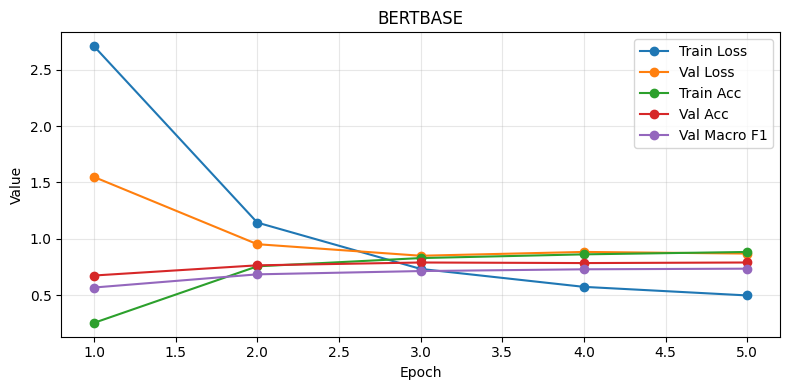

BERTBASE+CNN | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTBASE+CNN | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTBASE+CNN | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

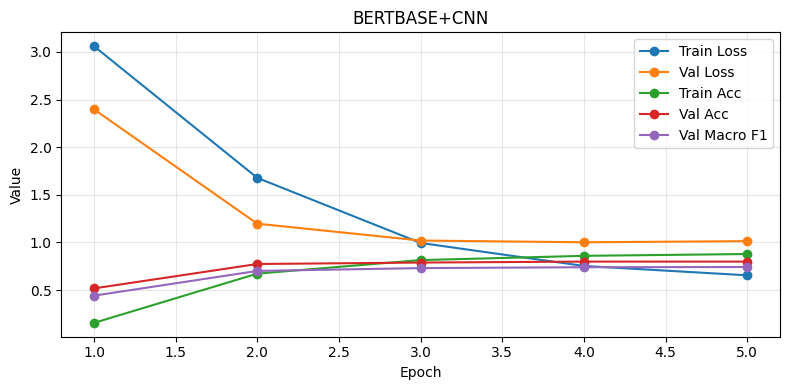

BERTIDF-CNN (Ours) | variant 1/4 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTIDF-CNN (Ours) | variant 1/4 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTIDF-CNN (Ours) | variant 4/4 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

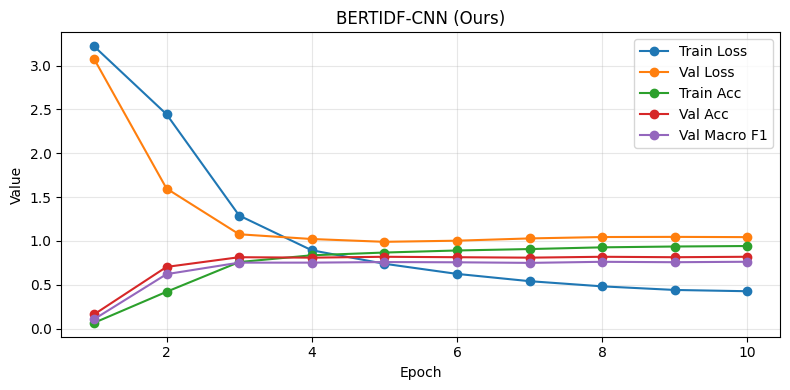

DistilBERT+CNN | variant 1/1 | seed 42


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBERT+CNN | variant 1/1 | seed 43


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBERT+CNN | variant 1/1 | seed 44


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

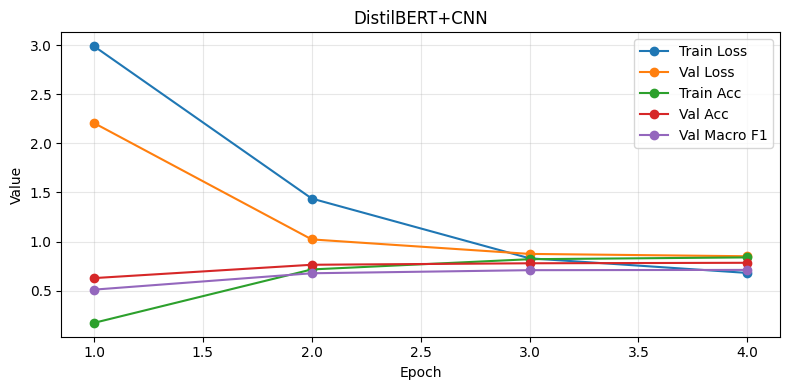

RoBERTaBASE+CNN | variant 1/1 | seed 42


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RoBERTaBASE+CNN | variant 1/1 | seed 43


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RoBERTaBASE+CNN | variant 1/1 | seed 44


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

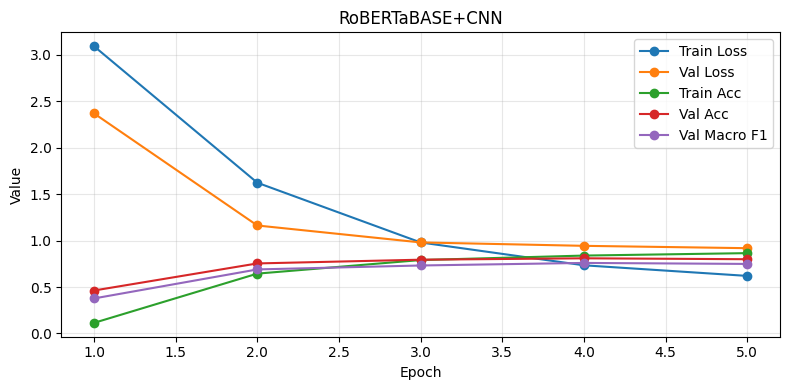

ALBERTBASE+CNN | variant 1/1 | seed 42


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

ALBERTBASE+CNN | variant 1/1 | seed 43


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

ALBERTBASE+CNN | variant 1/1 | seed 44


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

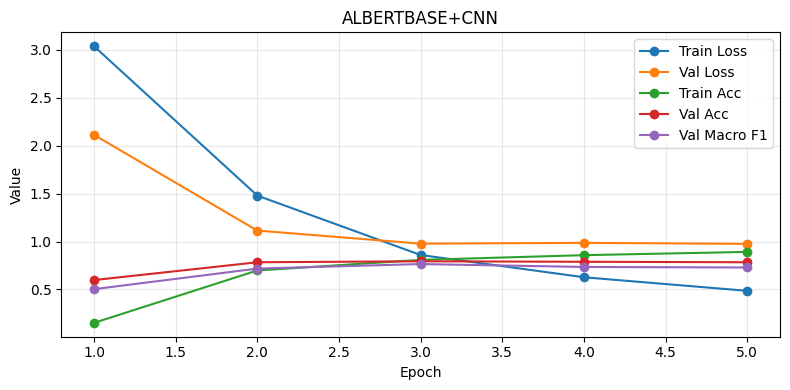

BERTLARGE | variant 1/1 | seed 42


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BERTLARGE | variant 1/1 | seed 43


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BERTLARGE | variant 1/1 | seed 44


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

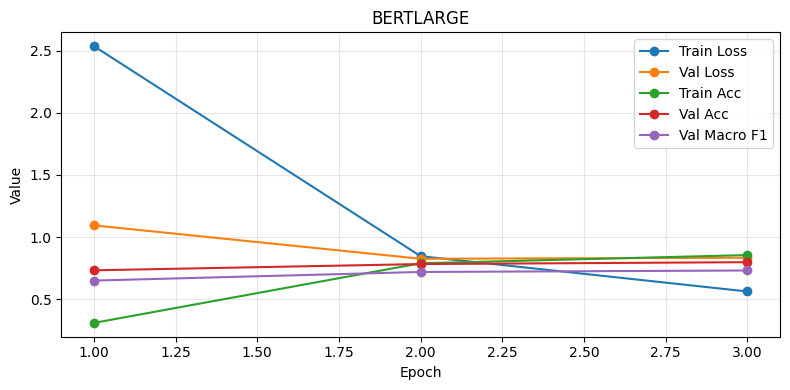

BERTLARGE+CNN | variant 1/1 | seed 42


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BERTLARGE+CNN | variant 1/1 | seed 43


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BERTLARGE+CNN | variant 1/1 | seed 44


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

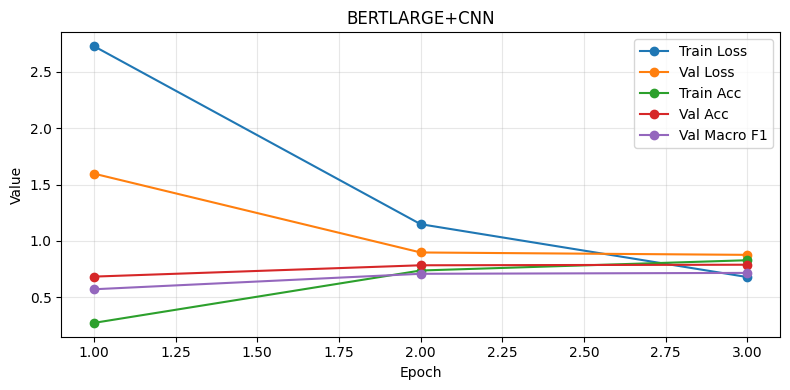

DeBERTaBASE | variant 1/1 | seed 42


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

DeBERTaBASE | variant 1/1 | seed 43


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DeBERTaBASE | variant 1/1 | seed 44


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

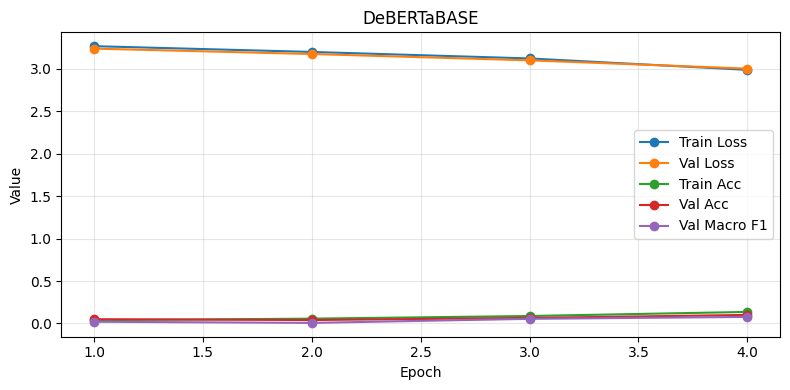

CLS pooling | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLS pooling | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLS pooling | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

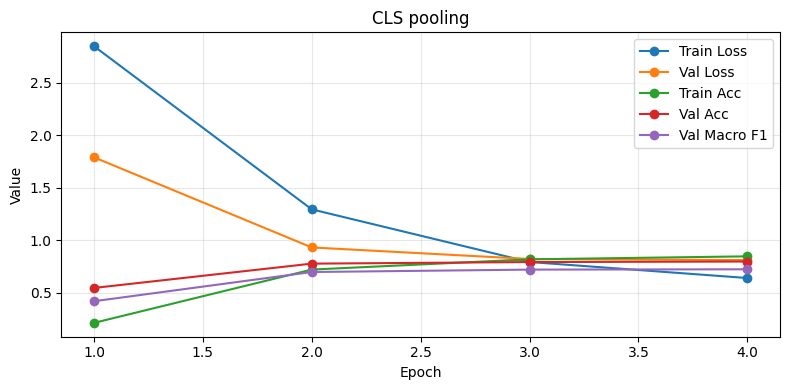

Mean pooling | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Mean pooling | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Mean pooling | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

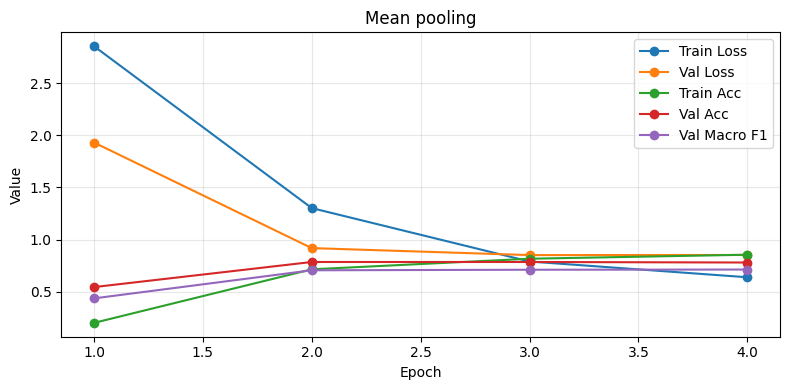

Softmax token attention | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Softmax token attention | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Softmax token attention | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

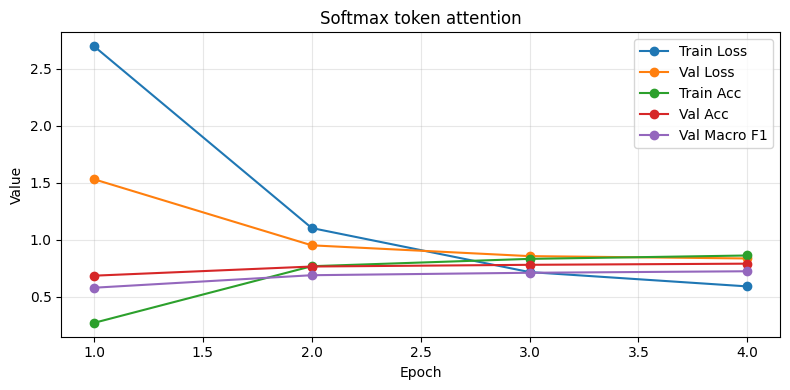

Layer scale | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Layer scale | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Layer scale | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

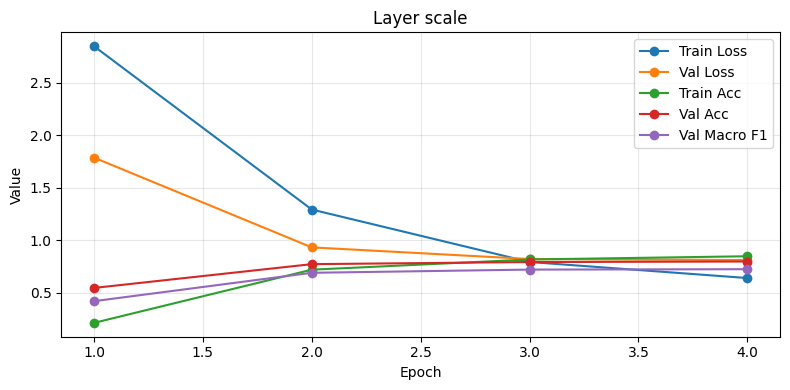

BERTIDF weighting | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTIDF weighting | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTIDF weighting | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

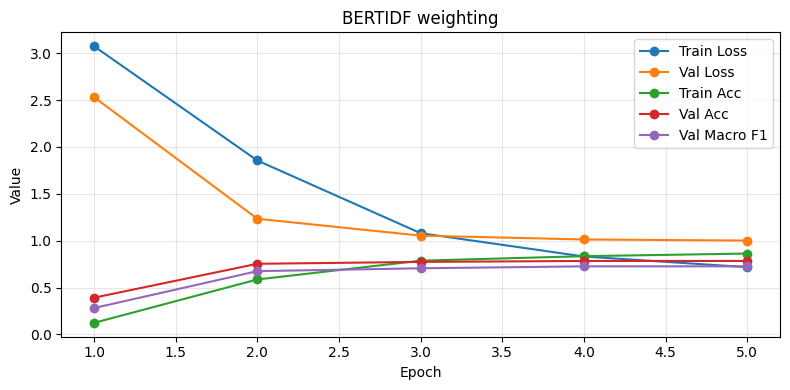

k = 2 | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

k = 2 | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

k = 2 | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

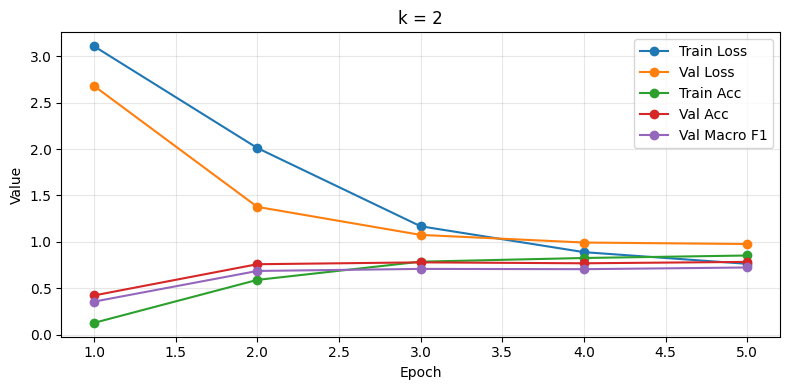

k = 3 | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

k = 3 | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

k = 3 | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

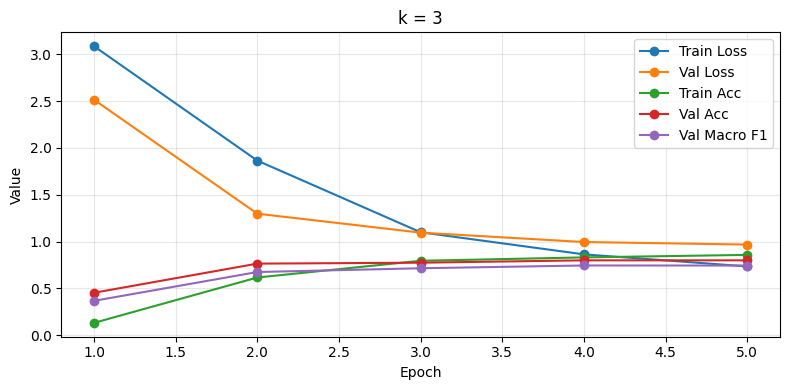

k = 4 | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

k = 4 | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

k = 4 | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

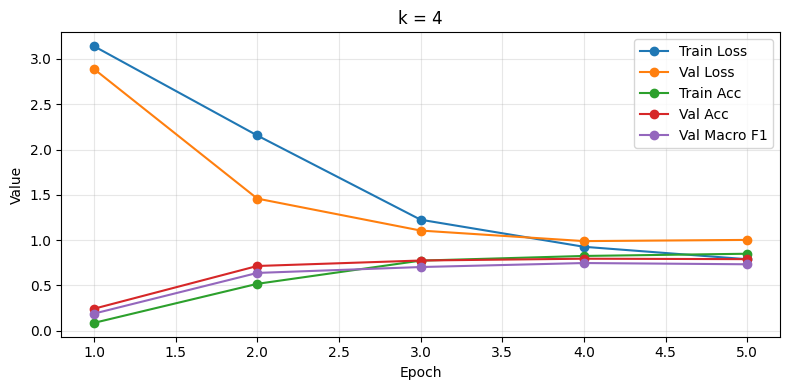

k = {2, 3} | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

k = {2, 3} | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

k = {2, 3} | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

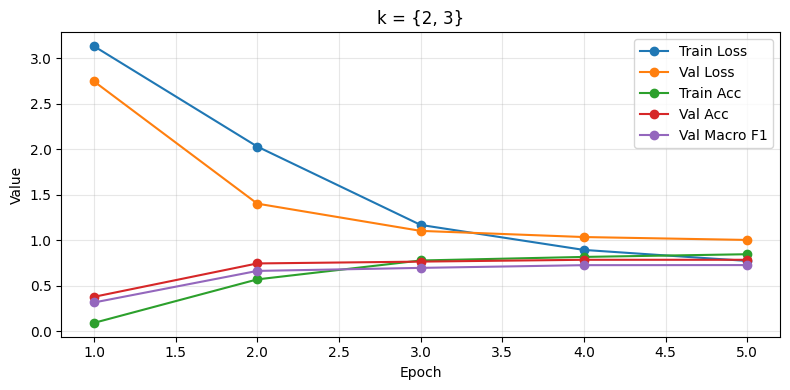

k = {3, 4} | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

k = {3, 4} | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

k = {3, 4} | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

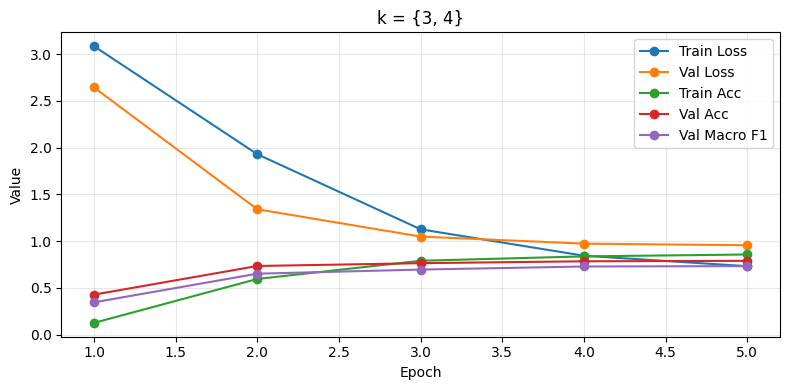

k = {2, 3, 4} | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

k = {2, 3, 4} | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

k = {2, 3, 4} | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

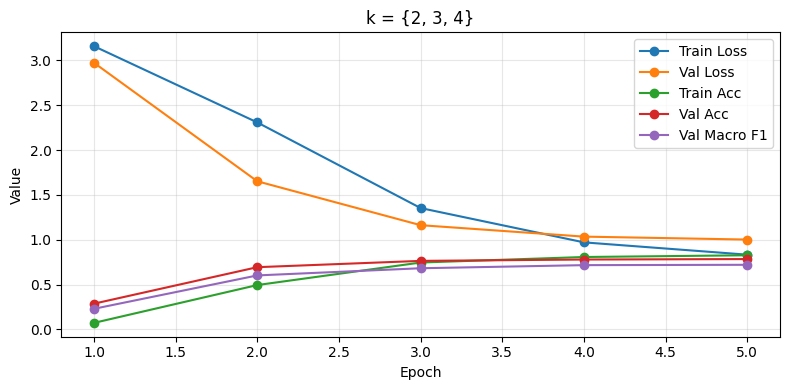

BERTBASE+CNN | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTBASE+CNN | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTBASE+CNN | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

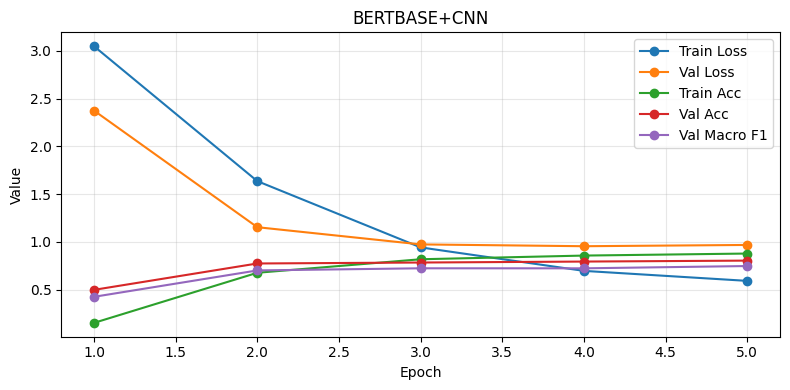

BERTIDF | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTIDF | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTIDF | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

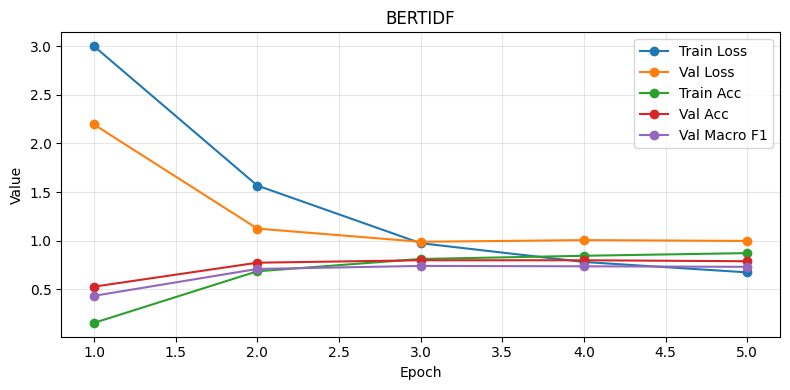

BERTIDF-CNN | variant 1/1 | seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTIDF-CNN | variant 1/1 | seed 43


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERTIDF-CNN | variant 1/1 | seed 44


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

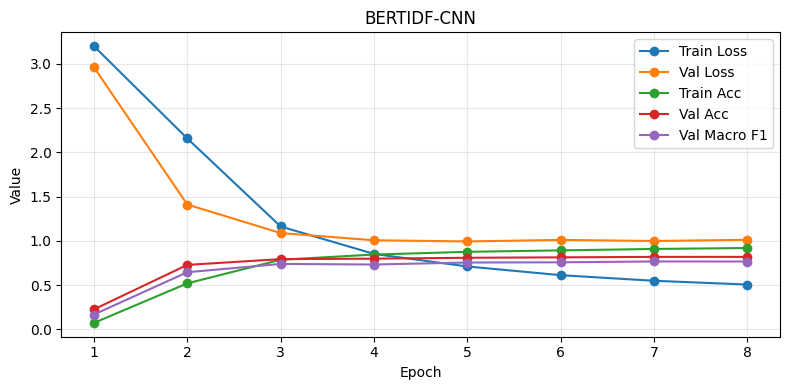

In [13]:
transformer_outputs = run_transformer_suite(core_specs)
attention_outputs = run_transformer_suite(attention_specs)
kernel_outputs = run_transformer_suite(kernel_specs)
hybrid_outputs = run_transformer_suite(hybrid_specs)


## Training curves and confusion matrices

In [20]:
from math import ceil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

all_outputs = {}
if "classical_outputs" in globals():
    all_outputs.update(classical_outputs)
if "lstm_output" in globals():
    all_outputs["LSTM"] = lstm_output
if "transformer_outputs" in globals():
    all_outputs.update(transformer_outputs)

def plot_group_histories(outputs, models, title, ncols=2):
    models = [m for m in models if m in outputs and outputs[m].get("history")]
    if not models:
        print(f"No training history available for {title}.")
        return

    nrows = ceil(len(models) / ncols)
    fig, axes = plt.subplots(
        nrows * 2,
        ncols,
        figsize=(7 * ncols, 4.0 * nrows * 2),
        squeeze=False
    )

    for idx, model_name in enumerate(models):
        row_group = idx // ncols
        col = idx % ncols
        hist = pd.DataFrame(outputs[model_name]["history"])

        ax_acc = axes[row_group * 2][col]
        ax_loss = axes[row_group * 2 + 1][col]

        if "train_acc" in hist.columns:
            ax_acc.plot(hist["epoch"], hist["train_acc"], marker="o", label="Training Accuracy")
        if "val_acc" in hist.columns:
            ax_acc.plot(hist["epoch"], hist["val_acc"], marker="s", label=f"{model_name} Val_Acc")
        elif "val_macro_f1" in hist.columns:
            ax_acc.plot(hist["epoch"], hist["val_macro_f1"], marker="s", label=f"{model_name} Val_F1")

        ax_acc.set_title(model_name)
        ax_acc.set_xlabel("Epochs")
        ax_acc.set_ylabel("Accuracy / F1")
        ax_acc.grid(True, linestyle="--", alpha=0.5)
        ax_acc.legend()

        if "train_loss" in hist.columns:
            ax_loss.plot(hist["epoch"], hist["train_loss"], marker="o", label="Training Loss")
        if "val_loss" in hist.columns:
            ax_loss.plot(hist["epoch"], hist["val_loss"], marker="s", label=f"{model_name} Val_Loss")

        ax_loss.set_title(model_name)
        ax_loss.set_xlabel("Epochs")
        ax_loss.set_ylabel("Loss")
        ax_loss.grid(True, linestyle="--", alpha=0.5)
        ax_loss.legend()

    total_slots = nrows * ncols
    for idx in range(len(models), total_slots):
        row_group = idx // ncols
        col = idx % ncols
        axes[row_group * 2][col].axis("off")
        axes[row_group * 2 + 1][col].axis("off")

    fig.suptitle(title, fontsize=14, y=0.995)
    fig.tight_layout()
    plt.show()

def plot_confusion_matrices(outputs, models, class_names, normalize=True, ncols=2):
    models = [m for m in models if m in outputs and "y_true" in outputs[m] and "y_pred" in outputs[m]]
    if not models:
        print("No models available for confusion matrices.")
        return

    nrows = ceil(len(models) / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(7 * ncols, 5.5 * nrows),
        squeeze=False
    )

    for idx, model_name in enumerate(models):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]

        y_true = outputs[model_name]["y_true"]
        y_pred = outputs[model_name]["y_pred"]

        cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

        if normalize:
            denom = cm.sum(axis=1, keepdims=True)
            denom[denom == 0] = 1
            cm = cm.astype(float) / denom

        im = ax.imshow(cm, interpolation="nearest")
        ax.set_title(model_name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

        tick_step = max(1, len(class_names) // 12)
        tick_idx = list(range(0, len(class_names), tick_step))
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([class_names[i] for i in tick_idx], rotation=90, fontsize=8)
        ax.set_yticks(tick_idx)
        ax.set_yticklabels([class_names[i] for i in tick_idx], fontsize=8)

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    total_slots = nrows * ncols
    for idx in range(len(models), total_slots):
        r, c = divmod(idx, ncols)
        axes[r][c].axis("off")

    fig.tight_layout()
    plt.show()

curve_groups = {
    "Core transformer benchmarks": [
        m for m in [
            "BERTBASE",
            "BERTBASE+CNN",
            "BERTIDF-CNN (Ours)",
            "DistilBERT+CNN",
            "RoBERTaBASE+CNN",
            "ALBERTBASE+CNN",
        ] if m in all_outputs
    ],
    "Heavy transformer benchmarks": [
        m for m in [
            "BERTLARGE",
            "BERTLARGE+CNN",
            "DeBERTaBASE",
        ] if m in all_outputs
    ],
    "Sequence models": [
        m for m in ["LSTM"] if m in all_outputs
    ],
}

for group_name, group_models in curve_groups.items():
    plot_group_histories(all_outputs, group_models, group_name, ncols=2)

confusion_models = [
    m for m in [
        "BERTBASE",
        "BERTBASE+CNN",
        "BERTIDF-CNN (Ours)",
        "RoBERTaBASE+CNN",
        "BERTLARGE+CNN",
        "DeBERTaBASE",
    ] if m in all_outputs
]

plot_confusion_matrices(
    all_outputs,
    confusion_models,
    label_order,
    normalize=True,
    ncols=2,
)

## Isotropy analysis


In [22]:
def build_embedding_loader(frame, tokenizer_name="bert-base-uncased", max_length=CONFIG["max_length"]):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, use_fast=True)
    return tokenizer, make_loader(frame, tokenizer, max_length, batch_size=16, shuffle=False, use_idf=True)

def average_pairwise_cosine(x, max_vectors=1500):
    if x.shape[0] > max_vectors:
        idx = np.random.RandomState(42).choice(x.shape[0], size=max_vectors, replace=False)
        x = x[idx]
    x = torch.tensor(x, dtype=torch.float32)
    x = F.normalize(x, p=2, dim=1)
    sim = x @ x.T
    tri = torch.triu_indices(sim.shape[0], sim.shape[1], offset=1)
    return float(sim[tri[0], tri[1]].mean().item())

def run_isotropy_analysis(frame):
    tokenizer, loader = build_embedding_loader(frame)
    model = TransformerClassifier(
        backbone="bert-base-uncased",
        num_classes=len(label_order),
        use_cnn=False,
        use_idf=False,
        attention_variant="cls",
    ).to(device)
    # use the trained BERTBASE weights when available
    if "BERTBASE" in transformer_outputs:
        model.load_state_dict(transformer_outputs["BERTBASE"]["model_state"], strict=False)

    raw_vectors, weighted_vectors = [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch_gpu = {k: v.to(device) for k, v in batch.items()}
            out = model(
                input_ids=batch_gpu["input_ids"],
                attention_mask=batch_gpu["attention_mask"],
                token_type_ids=batch_gpu.get("token_type_ids"),
            )
            hidden = model.encoder(
                input_ids=batch_gpu["input_ids"],
                attention_mask=batch_gpu["attention_mask"],
                token_type_ids=batch_gpu.get("token_type_ids"),
            ).last_hidden_state
            cls_raw = hidden[:, 0, :].detach().cpu().numpy()
            cls_weighted = (hidden * batch_gpu["idf_weights"].unsqueeze(-1)).mean(dim=1).detach().cpu().numpy()
            raw_vectors.append(cls_raw)
            weighted_vectors.append(cls_weighted)

    raw_vectors = np.concatenate(raw_vectors, axis=0)
    weighted_vectors = np.concatenate(weighted_vectors, axis=0)

    raw_cos = average_pairwise_cosine(raw_vectors)
    weighted_cos = average_pairwise_cosine(weighted_vectors)
    rel_change = (weighted_cos - raw_cos) / raw_cos if raw_cos != 0 else np.nan

    return pd.DataFrame(
        [
            {"Embedding Type": "BERTBASE Contextual Embeddings", "Avg. Cosine Similarity": round(raw_cos, 4), "Relative Change": np.nan},
            {"Embedding Type": "BERTIDF-CNN Weighted Embeddings", "Avg. Cosine Similarity": round(weighted_cos, 4), "Relative Change": round(rel_change, 4)},
        ]
    )

table_24_isotropy = run_isotropy_analysis(test_df)
table_24_isotropy


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,Embedding Type,Avg. Cosine Similarity,Relative Change
0,BERTBASE Contextual Embeddings,0.1108,NaN
1,BERTIDF-CNN Weighted Embeddings,0.0522,-0.5292


## Table builders


In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_recall_fscore_support

all_outputs = {}
all_outputs.update(classical_outputs)
all_outputs["LSTM"] = lstm_output
all_outputs.update(transformer_outputs)


def build_label_tables(report_dict, label_order, model_name):
    def _safe(section_key, metric_key):
        section = report_dict.get(section_key, {})
        value = section.get(metric_key, np.nan)
        try:
            return float(value)
        except Exception:
            return np.nan

    classes = list(label_order)
    total_support = int(np.nansum([_safe(cls, "support") for cls in classes]))

    row_labels = classes + ["Macro avg", "Weighted avg"]
    support_vals = [
        int(_safe(cls, "support")) if not pd.isna(_safe(cls, "support")) else np.nan
        for cls in classes
    ] + [total_support, total_support]

    precision_vals = [_safe(cls, "precision") for cls in classes] + [
        _safe("macro avg", "precision"),
        _safe("weighted avg", "precision"),
    ]
    recall_vals = [_safe(cls, "recall") for cls in classes] + [
        _safe("macro avg", "recall"),
        _safe("weighted avg", "recall"),
    ]
    f1_vals = [_safe(cls, "f1-score") for cls in classes] + [
        _safe("macro avg", "f1-score"),
        _safe("weighted avg", "f1-score"),
    ]

    precision_df = pd.DataFrame(
        {
            "Class": row_labels,
            model_name: precision_vals,
            "Support": support_vals,
        }
    )

    recall_df = pd.DataFrame(
        {
            "Class": row_labels,
            model_name: recall_vals,
            "Support": support_vals,
        }
    )

    f1_df = pd.DataFrame(
        {
            "Class": row_labels,
            model_name: f1_vals,
            "Support": support_vals,
        }
    )

    return precision_df, recall_df, f1_df


def merge_metric_tables(frames):
    if not frames:
        return pd.DataFrame(columns=["Class", "Support"])

    merged = frames[0].copy()

    for frame in frames[1:]:
        merged = merged.merge(
            frame.drop(columns=["Support"], errors="ignore"),
            on="Class",
            how="outer",
        )

    model_cols = [c for c in merged.columns if c not in ["Class", "Support"]]
    merged = merged[["Class"] + model_cols + ["Support"]]
    return merged


def build_table_10(outputs):
    rows = []
    for name, out in outputs.items():
        rows.append(
            {
                "Model": name,
                "Accuracy (%)": round(out["accuracy"] * 100, 2),
                "Macro F1": round(out["macro_f1"], 4),
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values(["Accuracy (%)", "Macro F1"], ascending=False)
        .reset_index(drop=True)
    )


def build_table_17(outputs, selected_models):
    rows = []
    for name in selected_models:
        out = outputs[name]
        rows.append(
            {
                "Model": name,
                "Macro F1": round(out["macro_f1"], 4),
                "Micro F1": round(
                    f1_score(out["y_true"], out["y_pred"], average="micro"), 4
                ),
                "Macro Prec.": round(out["macro_precision"], 4),
                "Micro Prec.": round(
                    precision_recall_fscore_support(
                        out["y_true"],
                        out["y_pred"],
                        average="micro",
                        zero_division=0,
                    )[0],
                    4,
                ),
                "Macro Rec.": round(out["macro_recall"], 4),
                "Micro Rec.": round(
                    precision_recall_fscore_support(
                        out["y_true"],
                        out["y_pred"],
                        average="micro",
                        zero_division=0,
                    )[1],
                    4,
                ),
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values(["Macro F1", "Micro F1"], ascending=False)
        .reset_index(drop=True)
    )


def build_table_20(outputs, selected_models):
    rows = []
    for name in selected_models:
        out = outputs[name]
        rows.append(
            {
                "Model": name,
                "Train Time / Epoch (s)": round(float(out["train_time_epoch_s"]), 2)
                if not pd.isna(out["train_time_epoch_s"])
                else np.nan,
                "Total Inference Time (s)": round(float(out["inference_total_s"]), 2),
                "Accuracy (%)": round(out["accuracy"] * 100, 2),
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values("Accuracy (%)", ascending=False)
        .reset_index(drop=True)
    )


def build_table_21(outputs, selected_models):
    rows = []
    test_count = len(test_df)
    for name in selected_models:
        out = outputs[name]
        rows.append(
            {
                "Model": name,
                "Training Time / Epoch (s)": round(float(out["train_time_epoch_s"]), 2)
                if not pd.isna(out["train_time_epoch_s"])
                else np.nan,
                "Inference Time (ms/doc)": round(
                    (float(out["inference_total_s"]) / max(test_count, 1)) * 1000, 3
                ),
                "GPU Memory (GB)": round(float(out["gpu_memory_gb"]), 3)
                if not pd.isna(out["gpu_memory_gb"])
                else np.nan,
                "Trainable Params (M)": round(float(out["params"]) / 1e6, 3)
                if not pd.isna(out["params"])
                else np.nan,
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values("Inference Time (ms/doc)")
        .reset_index(drop=True)
    )


def build_table_23(outputs, selected_models):
    rows = []
    for name in selected_models:
        out = outputs[name]
        params_m = float(out["params"]) / 1e6 if not pd.isna(out["params"]) else np.nan
        rows.append(
            {
                "Model Scale": name,
                "Trainable Params (M)": round(params_m, 3)
                if not pd.isna(params_m)
                else np.nan,
                "Accuracy (%)": round(out["accuracy"] * 100, 2),
                "Macro F1": round(out["macro_f1"], 4),
                "Inference Time (ms/doc)": round(
                    (out["inference_total_s"] / len(test_df)) * 1000, 3
                ),
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values(["Accuracy (%)", "Macro F1"], ascending=False)
        .reset_index(drop=True)
    )


def build_table_25(outputs):
    selected = ["BERTBASE", "BERTBASE+CNN", "BERTIDF-CNN (Ours)"]
    rows = []
    for name in selected:
        if name not in outputs:
            continue
        out = outputs[name]
        rows.append(
            {
                "Model": name,
                "Accuracy (%)": round(out["accuracy"] * 100, 2),
                "Macro F1": round(out["macro_f1"], 4),
                "Macro Precision": round(out["macro_precision"], 4),
                "Macro Recall": round(out["macro_recall"], 4),
            }
        )
    return pd.DataFrame(rows)


def build_table_26(outputs):
    selected = [
        "DistilBERT+CNN",
        "ALBERTBASE+CNN",
        "BERTBASE",
        "BERTBASE+CNN",
        "BERTIDF-CNN (Ours)",
    ]
    rows = []
    for name in selected:
        if name not in outputs:
            continue
        out = outputs[name]
        rows.append(
            {
                "Model": name,
                "Docs / second": round(
                    len(test_df) / max(out["inference_total_s"], 1e-9), 3
                ),
                "Inference Time (ms/doc)": round(
                    (out["inference_total_s"] / len(test_df)) * 1000, 3
                ),
                "Accuracy (%)": round(out["accuracy"] * 100, 2),
                "Macro F1": round(out["macro_f1"], 4),
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values("Docs / second", ascending=False)
        .reset_index(drop=True)
    )


def build_table_2(outputs):
    groups = {
        "Classical ML": [
            "SVM (TF-IDF)",
            "LogReg (TF-IDF)",
            "MultinomialNB",
            "Random Forest",
        ],
        "Recurrent": ["LSTM"],
        "Transformer": [
            m for m in ["BERTBASE", "BERTLARGE", "DeBERTaBASE"] if m in outputs
        ],
        "Hybrid Transformer": [
            m
            for m in [
                "BERTBASE+CNN",
                "BERTLARGE+CNN",
                "DistilBERT+CNN",
                "RoBERTaBASE+CNN",
                "ALBERTBASE+CNN",
                "BERTIDF-CNN (Ours)",
            ]
            if m in outputs
        ],
    }

    rows = []
    for family, members in groups.items():
        vals_acc = [outputs[m]["accuracy"] * 100 for m in members if m in outputs]
        vals_f1 = [outputs[m]["macro_f1"] for m in members if m in outputs]
        if not vals_acc:
            continue
        rows.append(
            {
                "Method Family": family,
                "Members": ", ".join(members),
                "Accuracy Range (%)": f"{min(vals_acc):.2f} - {max(vals_acc):.2f}",
                "Macro-F1 Range": f"{min(vals_f1):.4f} - {max(vals_f1):.4f}",
            }
        )
    return pd.DataFrame(rows)


def build_table_4(attention_outputs):
    rows = []
    for name, out in attention_outputs.items():
        rows.append(
            {
                "Re-weighting Strategy": name,
                "Accuracy (%)": round(out["accuracy"] * 100, 2),
                "Macro F1": round(out["macro_f1"], 4),
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values(["Accuracy (%)", "Macro F1"], ascending=False)
        .reset_index(drop=True)
    )


def build_table_13(hybrid_outputs):
    rows = []
    for name, out in hybrid_outputs.items():
        rows.append(
            {
                "Hybrid Model": name,
                "Accuracy (%)": round(out["accuracy"] * 100, 2),
                "Macro F1": round(out["macro_f1"], 4),
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values(["Accuracy (%)", "Macro F1"], ascending=False)
        .reset_index(drop=True)
    )


def build_table_22(kernel_outputs):
    rows = []
    for name, out in kernel_outputs.items():
        rows.append(
            {
                "Kernel Sizes": name,
                "Accuracy (%)": round(out["accuracy"] * 100, 2),
                "Macro F1": round(out["macro_f1"], 4),
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values(["Accuracy (%)", "Macro F1"], ascending=False)
        .reset_index(drop=True)
    )


def build_table_24_isotropy(outputs):
    selected = [
        "BERTBASE",
        "BERTBASE+CNN",
        "BERTIDF-CNN (Ours)",
        "RoBERTaBASE+CNN",
        "ALBERTBASE+CNN",
        "BERTLARGE+CNN",
        "DeBERTaBASE",
    ]
    rows = []
    for name in selected:
        if name not in outputs:
            continue

        out = outputs[name]
        row = {"Model": name}
        has_iso = False

        for src_key, dst_key in [
            ("isotropy_before", "Isotropy Before"),
            ("isotropy_after", "Isotropy After"),
            ("anisotropy_before", "Anisotropy Before"),
            ("anisotropy_after", "Anisotropy After"),
            ("isotropy_gain", "Isotropy Gain"),
            ("anisotropy_gain", "Anisotropy Gain"),
        ]:
            if (
                src_key in out
                and out[src_key] is not None
                and not pd.isna(out[src_key])
            ):
                row[dst_key] = round(float(out[src_key]), 4)
                has_iso = True

        if not has_iso:
            row["Accuracy (%)"] = round(out["accuracy"] * 100, 2)
            row["Macro F1"] = round(out["macro_f1"], 4)
            row["Macro Precision"] = round(out["macro_precision"], 4)
            row["Macro Recall"] = round(out["macro_recall"], 4)

        rows.append(row)

    return pd.DataFrame(rows)


selected_article_models = [
    m
    for m in [
        "BERTBASE",
        "BERTBASE+CNN",
        "BERTLARGE",
        "BERTLARGE+CNN",
        "DistilBERT+CNN",
        "RoBERTaBASE+CNN",
        "ALBERTBASE+CNN",
        "BERTIDF-CNN (Ours)",
    ]
    if m in all_outputs
]

precision_frames, recall_frames, f1_frames = [], [], []
for name in selected_article_models:
    p, r, f = build_label_tables(all_outputs[name]["report"], label_order, name)
    precision_frames.append(p)
    recall_frames.append(r)
    f1_frames.append(f)

table_2 = build_table_2(all_outputs)
table_4 = build_table_4(attention_outputs)
table_10 = build_table_10(all_outputs)
table_13 = build_table_13(hybrid_outputs)
table_14 = merge_metric_tables(precision_frames)
table_15 = merge_metric_tables(recall_frames)
table_16 = merge_metric_tables(f1_frames)
table_17 = build_table_17(all_outputs, selected_article_models)
table_20 = build_table_20(all_outputs, selected_article_models)
table_21 = build_table_21(
    all_outputs,
    [
        m
        for m in [
            "SVM (TF-IDF)",
            "Random Forest",
            "LSTM",
            "BERTBASE",
            "BERTBASE+CNN",
            "BERTLARGE",
            "BERTLARGE+CNN",
            "DistilBERT+CNN",
            "RoBERTaBASE+CNN",
            "DeBERTaBASE",
            "BERTIDF-CNN (Ours)",
        ]
        if m in all_outputs
    ],
)
table_22 = build_table_22(kernel_outputs)
table_23 = build_table_23(
    all_outputs,
    [
        m
        for m in [
            "DistilBERT+CNN",
            "ALBERTBASE+CNN",
            "BERTBASE",
            "BERTBASE+CNN",
            "RoBERTaBASE+CNN",
            "DeBERTaBASE",
            "BERTLARGE",
            "BERTLARGE+CNN",
            "BERTIDF-CNN (Ours)",
        ]
        if m in all_outputs
    ],
)
table_24_isotropy = build_table_24_isotropy(all_outputs)
table_25 = build_table_25(all_outputs)
table_26 = build_table_26(all_outputs)

table_11 = (
    pd.DataFrame(
        [
            {
                "Model": "TF-IDF + Linear SVM",
                "Source": "current execution",
                "Accuracy (%)": round(
                    classical_outputs["SVM (TF-IDF)"]["accuracy"] * 100, 2
                ),
                "Macro F1": round(
                    classical_outputs["SVM (TF-IDF)"]["macro_f1"], 4
                ),
            },
            {
                "Model": "Random Forest",
                "Source": "current execution",
                "Accuracy (%)": round(
                    classical_outputs["Random Forest"]["accuracy"] * 100, 2
                ),
                "Macro F1": round(
                    classical_outputs["Random Forest"]["macro_f1"], 4
                ),
            },
            {
                "Model": "BiLSTM",
                "Source": "current execution",
                "Accuracy (%)": round(lstm_output["accuracy"] * 100, 2),
                "Macro F1": round(lstm_output["macro_f1"], 4),
            },
            {
                "Model": "BERTBASE",
                "Source": "current execution",
                "Accuracy (%)": round(all_outputs["BERTBASE"]["accuracy"] * 100, 2),
                "Macro F1": round(all_outputs["BERTBASE"]["macro_f1"], 4),
            },
            {
                "Model": "BERTBASE+CNN",
                "Source": "current execution",
                "Accuracy (%)": round(
                    all_outputs["BERTBASE+CNN"]["accuracy"] * 100, 2
                ),
                "Macro F1": round(
                    all_outputs["BERTBASE+CNN"]["macro_f1"], 4
                ),
            },
            {
                "Model": "BERTIDF-CNN (Ours)",
                "Source": "current execution",
                "Accuracy (%)": round(
                    all_outputs["BERTIDF-CNN (Ours)"]["accuracy"] * 100, 2
                ),
                "Macro F1": round(
                    all_outputs["BERTIDF-CNN (Ours)"]["macro_f1"], 4
                ),
            },
        ]
    )
    .sort_values(["Accuracy (%)", "Macro F1"], ascending=False)
    .reset_index(drop=True)
)

resume_tables = {
    "table_2": table_2,
    "table_4": table_4,
    "table_10": table_10,
    "table_11": table_11,
    "table_13": table_13,
    "table_14": table_14,
    "table_15": table_15,
    "table_16": table_16,
    "table_17": table_17,
    "table_20": table_20,
    "table_21": table_21,
    "table_22": table_22,
    "table_23": table_23,
    "table_24": table_24_isotropy,
    "table_25": table_25,
    "table_26": table_26,
}


## Tables


In [23]:
for name, frame in resume_tables.items():
    print("\n" + name)
    display(frame)



table_2


,Method Family,Members,Accuracy Range (%),Macro-F1 Range
0,Classical ML,"SVM (TF-IDF), LogReg (TF-IDF), MultinomialNB, ...",51.51 - 70.82,0.4182 - 0.6355
1,Recurrent,LSTM,14.29 - 14.29,0.1275 - 0.1275
2,Transformer,"BERTBASE, BERTLARGE, DeBERTaBASE",13.68 - 82.29,0.0906 - 0.7709
3,Hybrid Transformer,"BERTBASE+CNN, BERTLARGE+CNN, DistilBERT+CNN, R...",79.48 - 83.50,0.7370 - 0.7974



table_4


,Re-weighting Strategy,Accuracy (%),Macro F1
0,Softmax token attention,81.09,0.7383
1,CLS pooling,80.68,0.7369
2,Layer scale,80.68,0.7369
3,Mean pooling,80.48,0.7352
4,BERTIDF weighting,80.28,0.7700



table_10


...

,Model,Accuracy (%),Macro F1,Macro Precision,Macro Recall
0,BERTBASE,81.49,0.7709,0.8168,0.7680
1,BERTBASE+CNN,81.09,0.7700,0.7716,0.7774
2,BERTIDF-CNN (Ours),83.50,0.7974,0.7991,0.8004
3,RoBERTaBASE+CNN,79.88,0.7579,0.7631,0.7628
4,ALBERTBASE+CNN,79.48,0.7633,0.7879,0.7626
5,BERTLARGE+CNN,81.89,0.7479,0.7486,0.7568
6,DeBERTaBASE,13.68,0.0906,0.0976,0.1242



table_25


,Model,Accuracy (%),Macro F1,Macro Precision,Macro Recall
0,BERTBASE,81.49,0.7709,0.8168,0.7680
1,BERTBASE+CNN,81.09,0.7700,0.7716,0.7774
2,BERTIDF-CNN (Ours),83.50,0.7974,0.7991,0.8004



table_26


,Model,Docs / second,Inference Time (ms/doc),Accuracy (%),Macro F1
0,BERTBASE,203.670,4.910,81.49,0.7709
1,DistilBERT+CNN,201.652,4.959,80.68,0.7370
2,BERTBASE+CNN,198.443,5.039,81.09,0.7700
3,ALBERTBASE+CNN,180.248,5.548,79.48,0.7633
4,BERTIDF-CNN (Ours),164.696,6.072,83.50,0.7974
